# **Phase 3: Data Understanding**

# ***3.1. Cài đặt và import thư viện***

In [1]:
!pip install ucimlrepo pandas seaborn matplotlib

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

# ***3.2. Tải dataset từ UCI***

In [3]:
student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y = student_performance.data.targets

# ***3.3 Xem metadata dataset***

In [4]:
print(student_performance.metadata)

{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

# ***3.4. Xem thông tin từng biến***

In [5]:
print(student_performance.variables)

          name     role         type      demographic  \
0       school  Feature  Categorical             None   
1          sex  Feature       Binary              Sex   
2          age  Feature      Integer              Age   
3      address  Feature  Categorical             None   
4      famsize  Feature  Categorical            Other   
5      Pstatus  Feature  Categorical            Other   
6         Medu  Feature      Integer  Education Level   
7         Fedu  Feature      Integer  Education Level   
8         Mjob  Feature  Categorical       Occupation   
9         Fjob  Feature  Categorical       Occupation   
10      reason  Feature  Categorical             None   
11    guardian  Feature  Categorical             None   
12  traveltime  Feature      Integer             None   
13   studytime  Feature      Integer             None   
14    failures  Feature      Integer             None   
15   schoolsup  Feature       Binary             None   
16      famsup  Feature       B

# ***3.5. Ghép features và target***

In [6]:
df = pd.concat([X, y], axis=1)
df.head() #Preview 5 dòng đầu tiên

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


# ***3.6. Kiểm tra kích thước dataset***

In [7]:
df.shape

(649, 33)

# ***3.7. Kiểm tra kiểu dữ liệu***

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

# ***3.8. Thống kê mô tả***

In [9]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


# ***3.9. Kiểm tra missing value***

In [10]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


# ***3.10. Kiểm tra duplicate***

In [11]:
df.duplicated().sum()

np.int64(0)

# ***3.11. Tạo biến target PASS/FAIL***

In [12]:
df["pass"] = (df["G3"] >= 10).astype(int)

# ***3.12. Kiểm tra phân bố PASS/FAIL***

In [13]:
df["pass"].value_counts()

,count
pass,
1,549
0,100


# ***3.13. Vẽ biểu đồ phân bố PASS/FAIL***

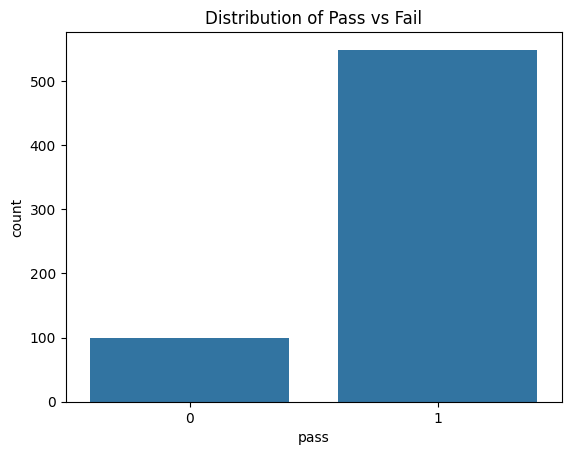

In [14]:
sns.countplot(x="pass", data=df)
plt.title("Distribution of Pass vs Fail")
plt.show()

# ***3.14. Tạo-nhóm-features***

In [15]:
# Demographic features
demographic_features = [
    "age", "sex", "address", "famsize", "Pstatus"
]

# Family background
family_features = [
    "Medu", "Fedu", "Mjob", "Fjob", "guardian"
]

# Academic behaviour
academic_features = [
    "studytime", "failures", "schoolsup", "famsup", "paid"
]

# Lifestyle features
lifestyle_features = [
    "activities", "internet", "romantic", "goout", "Dalc", "Walc"
]

# Academic grades
grade_features = [
    "G1", "G2", "G3"
]

print("Demographic:", demographic_features)
print("Family:", family_features)
print("Academic:", academic_features)
print("Lifestyle:", lifestyle_features)
print("Grades:", grade_features)

Demographic: ['age', 'sex', 'address', 'famsize', 'Pstatus']
Family: ['Medu', 'Fedu', 'Mjob', 'Fjob', 'guardian']
Academic: ['studytime', 'failures', 'schoolsup', 'famsup', 'paid']
Lifestyle: ['activities', 'internet', 'romantic', 'goout', 'Dalc', 'Walc']
Grades: ['G1', 'G2', 'G3']


# Phase 4: Exploratory Data Analysis (EDA)

# ***4.1. Phân bố điểm G3 (Điểm cuối kỳ)***

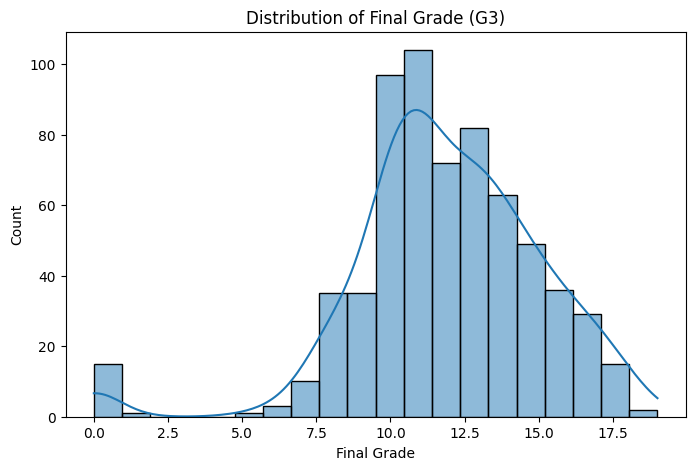

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20, kde=True)

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Count")

plt.show()

# ***4.2. Phân bố PASS/FAIL***

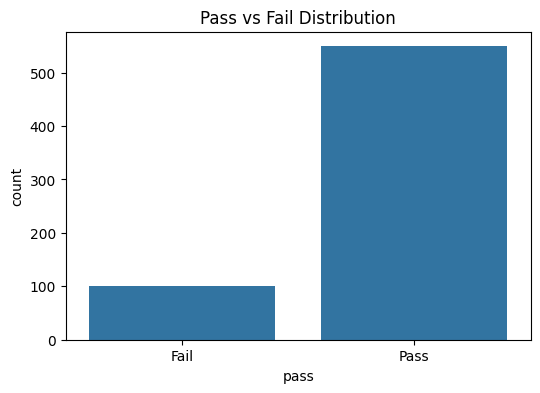

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='pass', data=df)

plt.title("Pass vs Fail Distribution")
plt.xticks([0,1],["Fail","Pass"])

plt.show()

# *4.3. Quan hệ tuyến tính thời gian học (Study Time) và tỷ lệ qua môn (PASS)*

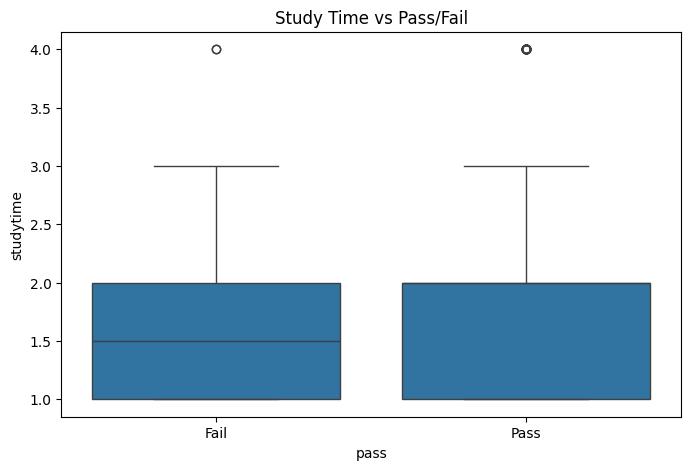

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x='pass', y='studytime', data=df)

plt.title("Study Time vs Pass/Fail")
plt.xticks([0,1],["Fail","Pass"])

plt.show()

# ***4.4. Quan hệ giữa số lần trượt môn (Failures) và tỷ lệ qua môn (Pass)***

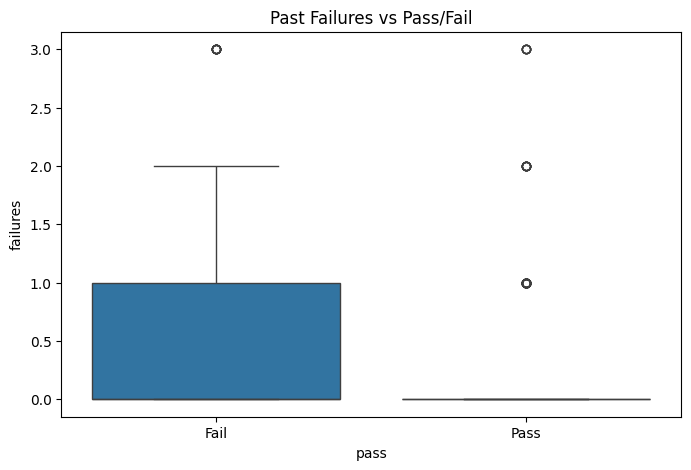

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x='pass', y='failures', data=df)

plt.title("Past Failures vs Pass/Fail")
plt.xticks([0,1],["Fail","Pass"])

plt.show()

# ***4.5. Quan hệ giữa yếu tố cuộc sống (Goout) và tỷ lệ qua môn (Pass)***

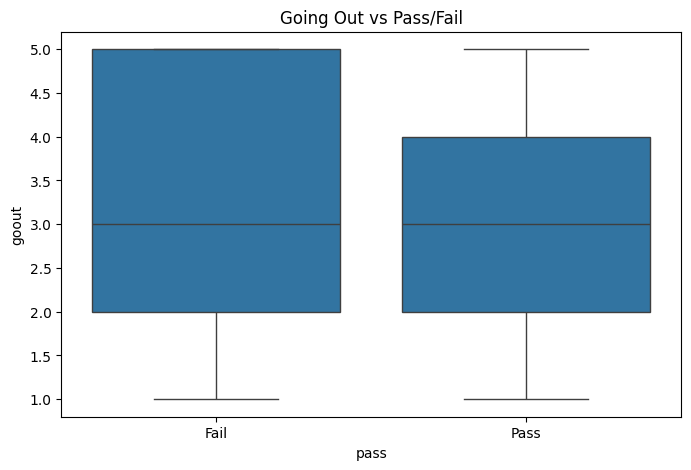

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x='pass', y='goout', data=df)

plt.title("Going Out vs Pass/Fail")
plt.xticks([0,1],["Fail","Pass"])

plt.show()

# ***4.6. Ma trận tương quan các biến số***

Mục tiêu: Xem các biến số trong dataset có liên hệ với nhau mạnh hay yếu.

Ví dụ:

* G1 có liên quan đến G3 không?

* G2 có ảnh hưởng đến G3 không?

* failures có liên quan đến điểm cuối kỳ không?

* studytime có thực sự giúp điểm cao hơn không?

**Hệ số tương quan có giá trị từ:**

* +1: tương quan dương hoàn toàn.

* 0: không có tương quan.

* -1: tương quan âm hoàn toàn.

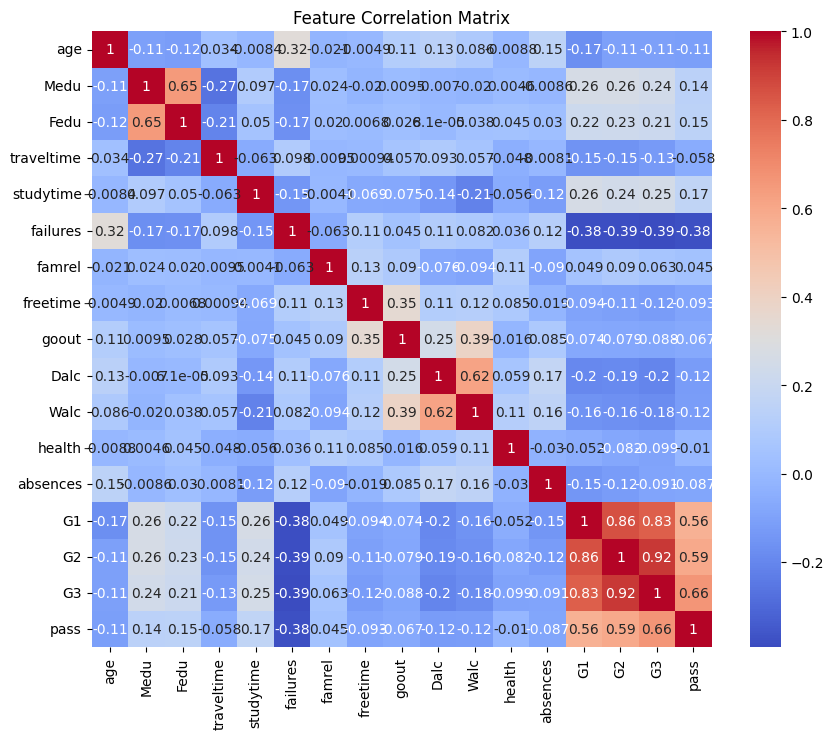

In [21]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

# **Phase 5: Data Preprocessing**

# ***5.1: Tạo bản sao dataset để xử lý***

In [22]:
df_processed = df.copy()

# ***5.2. Kiểm tra dữ liệu trùng lặp***

In [23]:
df_processed.duplicated().sum()

np.int64(0)

**Kết quả kiểm tra:** Không phát hiện dữ liệu trùng lặp, không cần thực hiện bước loại bỏ.

# ***5.3. Kiểm tra Missing Values***

In [24]:
df_processed.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


**Kết quả kiểm tra:** Không phát hiện dữ liệu thiếu.

# ***5.4. Tạo biến mục tiêu PASS/FAIL***

Trong dataset gốc:

* G1 = điểm giữa kỳ

* G2 = điểm giữa kỳ 2

* G3 = điểm cuối kỳ

Theo chuẩn dataset này, G3 được xác định:

* Giá trị điểm từ 0 – 20 điểm.

* Nếu G3 >=10 → Pass

* Nếu G3 <10 → Fail

In [25]:
df_processed["pass"] = (df_processed["G3"] >= 10).astype(int)

Kiểm tra phân bổ điểm cuối kì G3:

In [26]:
df_processed["pass"].value_counts()

,count
pass,
1,549
0,100


# ***5.5. Mã hóa các biến phân loại***

In [27]:
df_processed = pd.get_dummies(df_processed, drop_first=True)
df_processed = df_processed.astype(int)

Kích thước dataset sau khi thực hiện encoding (rows, columns):

In [28]:
df_processed.shape

(649, 43)

Preview dataset sau khi encoding (5 dòng đầu tiên):

In [29]:
df_processed.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,1,0,0,0,1,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0
2,15,1,1,1,2,0,4,3,2,2,...,1,0,1,0,0,0,1,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,1,0,0,1,0,1,1,1,1,1
4,16,3,3,1,2,0,4,3,2,1,...,0,0,0,1,0,0,1,1,0,0


Kiểm tra kiểu dữ liệu các cột, đảm bảo tất cả đã được encoding sang dạng Binary:

In [30]:
df_processed.dtypes

,0
age,int64
Medu,int64
Fedu,int64
traveltime,int64
studytime,int64
failures,int64
famrel,int64
freetime,int64
goout,int64
Dalc,int64


**Kết quả kiểm tra:** Tất cả các cột đều có dữ liệu dạng int64

# ***5.6. Loại bỏ các biến gây rò rỉ dữ liệu (Data Leakage)***

G3 chứa thông tin trực tiếp về label. Nếu giữ G3 trong feature thì model sẽ biết luôn đáp án, dẫn đến kết quả dự đoán gần như 100% nhưng không có ý nghĩa thực tế.

Ví dụ:

* G3 = 12 → pass = 1.

* G3 = 8  → pass = 0.

Nếu model nhìn thấy G3 thì nó chỉ cần học:

if G3 >= 10 → pass

→ độ chính xác gần 100% nhưng vô nghĩa.

Vì vậy G3 bắt buộc phải loại bỏ.

In [31]:
df_processed = df_processed.drop("G3", axis=1)

# ***5.7. Tách Feature và Target***

Sau khi xử lý xong dataset, ta tách:

X → đặc trưng (features) → Thông tin sinh viên.

y → nhãn (label) → Pass/Fail.

In [32]:
X = df_processed.drop("pass", axis=1)
y = df_processed["pass"]

# ***5.8. Chia dữ liệu Train/Test***

Dữ liệu cần được chia thành:

* test_size = 0.2 → 80% train, 20% test.

* random_state → để kết quả reproducible.

* stratify=y → giữ tỷ lệ pass/fail giống dataset gốc.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Kiểm tra kích thước dữ liệu trên tập train/test (rows, columns):

In [34]:
print(X_train.shape)
print(X_test.shape)

(519, 41)
(130, 41)


# ***5.9. Feature Scaling (Chuẩn hóa dữ liệu)***

Trong dataset Student Performance, các đặc trưng có thang đo rất khác nhau.

Ví dụ:

* Biến age chỉ nằm trong khoảng 15–22.

* Biến studytime có giá trị từ 1 đến 4.

* Biến absences có thể lên đến vài chục.

→ Nếu không chuẩn hóa, các thuật toán dựa trên khoảng cách hoặc gradient sẽ bị ảnh hưởng mạnh bởi những biến có giá trị lớn hơn.

**Mục tiêu:**

Biến đổi các giá trị số của các đặc trưng (features) về cùng một thang đo trước khi đưa vào mô hình học máy. Đảm bảo rằng các biến có giá trị lớn không “áp đảo” các biến có giá trị nhỏ trong quá trình học của mô hình.

Công thức chuẩn hóa dữ liệu:

**Standard Scaler:**

$$
x' = \frac{x - \mu}{\sigma}
$$

***Trong đó:***

* x' = Giá trị sau chuẩn hóa.

* x = Giá trị ban đầu.

* Giá trị trung bình (mean):

$$
mean = \mu = \frac{x_1 + x_2 + ... + x_n}{n}
$$

* Độ lệch chuẩn (std):

$$
std = \sigma = \sqrt{\frac{(x_1 - \mu)^2 + (x_2 - \mu)^2 + ... + (x_n - \mu)^2}{n}}
$$

StandardScaler được fit trên tập huấn luyện để tính toán các tham số thống kê như mean và standard deviation. Các tham số này sau đó được sử dụng để chuẩn hóa cả tập huấn luyện và tập kiểm tra. Việc chỉ fit scaler trên tập huấn luyện giúp tránh hiện tượng data leakage và đảm bảo rằng cả hai tập dữ liệu được chuẩn hóa theo cùng một thang đo.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Preview 5 dòng dữ liệu 2 tệp train/test sau khi chuẩn hóa dữ liệu:

In [36]:
import pandas as pd

# chuyển lại thành DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# preview 5 dòng đầu
print("Train set (scaled):")
display(X_train_scaled_df.head())

print("Test set (scaled):")
display(X_test_scaled_df.head())

Train set (scaled):


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,-0.591052,1.315936,1.535526,-0.731477,1.26341,-0.37338,1.122563,-0.157555,-0.146579,-0.5371,...,0.667595,-0.26477,-0.358135,0.788591,-0.260579,1.005797,0.479435,0.337245,0.566225,-0.750502
1,0.211974,-1.321017,-1.162910,-0.731477,1.26341,-0.37338,0.095032,-0.157555,0.698695,-0.5371,...,0.667595,-0.26477,-0.358135,0.788591,-0.260579,1.005797,0.479435,0.337245,-1.766083,1.332442
2,0.211974,0.436952,-0.263431,-0.731477,0.07121,1.25506,0.095032,1.700882,0.698695,-0.5371,...,-1.497915,-0.26477,-0.358135,-1.268085,-0.260579,-0.994236,0.479435,0.337245,-1.766083,1.332442
3,-1.394079,-0.442033,-0.263431,0.600581,0.07121,-0.37338,0.095032,-2.015993,-0.146579,-0.5371,...,0.667595,-0.26477,2.792241,0.788591,-0.260579,-0.994236,0.479435,0.337245,0.566225,-0.750502
4,-1.394079,1.315936,1.535526,-0.731477,0.07121,-0.37338,0.095032,0.771663,0.698695,-0.5371,...,-1.497915,-0.26477,2.792241,0.788591,-0.260579,1.005797,-2.085789,0.337245,0.566225,-0.750502


Test set (scaled):


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,-0.591052,0.436952,1.535526,-0.731477,0.071210,-0.37338,1.122563,-0.157555,-0.146579,-0.537100,...,0.667595,-0.26477,2.792241,0.788591,3.837613,1.005797,0.479435,0.337245,0.566225,-0.750502
1,-0.591052,-0.442033,-0.263431,-0.731477,0.071210,-0.37338,1.122563,0.771663,0.698695,-0.537100,...,0.667595,-0.26477,-0.358135,-1.268085,-0.260579,-0.994236,0.479435,0.337245,0.566225,1.332442
2,-0.591052,0.436952,1.535526,-0.731477,-1.120989,-0.37338,-0.932500,-1.086774,-1.837129,-0.537100,...,-1.497915,-0.26477,-0.358135,-1.268085,-0.260579,-0.994236,0.479435,0.337245,0.566225,-0.750502
3,1.015001,-0.442033,-0.263431,0.600581,1.263410,-0.37338,1.122563,-0.157555,-0.146579,-0.537100,...,0.667595,-0.26477,-0.358135,-1.268085,-0.260579,-0.994236,0.479435,0.337245,-1.766083,-0.750502
4,1.818027,-1.321017,-1.162910,-0.731477,0.071210,2.88350,0.095032,0.771663,-0.146579,1.640672,...,0.667595,-0.26477,-0.358135,0.788591,-0.260579,1.005797,0.479435,-2.965207,0.566225,-0.750502


# **Phase 6: Model Building**

Xây dựng 4 mô hình học máy (ML) bao gồm:

* Logistic Regression.

* Decision Tree.

* Random Forest.

* KNN.

Để đánh giá hiệu quả của mô hình phân loại, sử dụng bốn chỉ số: Accuracy, Precision, Recall và F1-score.

---

**Accuracy (Độ chính xác tổng thể)**: Là tỷ lệ dự đoán đúng của mô hình trên toàn bộ dữ liệu.

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

Trong đó:
* TP (True Positive): Dự đoán đúng lớp dương.

* TN (True Negative): Dự đoán đúng lớp âm.  

* FP (False Positive): Dự đoán dương nhưng thực tế âm.

* FN (False Negative): Dự đoán âm nhưng thực tế dương.  

***→ Accuracy cho biết mô hình dự đoán đúng bao nhiêu phần trăm tổng số mẫu.***

---
**Precision (Độ chính xác của dự đoán dương)**: Đo lường trong tất cả các trường hợp mô hình dự đoán là dương, có bao nhiêu trường hợp là đúng.

$$
Precision = \frac{TP}{TP + FP}
$$

***→ Precision cao cho thấy khi mô hình dự đoán positive thì khả năng đúng cao.***

---

**Recall (Độ bao phủ / Độ nhạy)**: Đo lường khả năng của mô hình trong việc phát hiện tất cả các trường hợp dương thực sự.

$$
Recall = \frac{TP}{TP + FN}
$$

***→ Recall cao nghĩa là mô hình phát hiện được nhiều trường hợp positive và ít bỏ sót.***

---

**F1-score:** Là trung bình điều hòa giữa Precision và Recall.

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

***→ F1-score giúp đánh giá cân bằng giữa Precision và Recall, đặc biệt hữu ích khi dữ liệu bị mất cân bằng.***

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# ***6.1. Logistic Regression (Baseline Model)***

In [38]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.9076923076923077

Confusion Matrix:
[[ 13   7]
 [  5 105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.65      0.68        20
           1       0.94      0.95      0.95       110

    accuracy                           0.91       130
   macro avg       0.83      0.80      0.82       130
weighted avg       0.90      0.91      0.91       130



# ***6.2. Decision Tree***

In [39]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train_scaled, y_train)

y_pred_tree = tree_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.8538461538461538

Confusion Matrix:
[[12  8]
 [11 99]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.60      0.56        20
           1       0.93      0.90      0.91       110

    accuracy                           0.85       130
   macro avg       0.72      0.75      0.74       130
weighted avg       0.86      0.85      0.86       130



# ***6.3. Random Forest***

In [40]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9

Confusion Matrix:
[[ 12   8]
 [  5 105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        20
           1       0.93      0.95      0.94       110

    accuracy                           0.90       130
   macro avg       0.82      0.78      0.80       130
weighted avg       0.89      0.90      0.90       130



# ***6.4. K-NN***

In [41]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.823076923076923

Confusion Matrix:
[[  2  18]
 [  5 105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.10      0.15        20
           1       0.85      0.95      0.90       110

    accuracy                           0.82       130
   macro avg       0.57      0.53      0.52       130
weighted avg       0.77      0.82      0.79       130



# ***6.5. So sánh kết quả 4 mô hình***

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "KNN"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.907692,0.937500,0.954545,0.945946
1,Decision Tree,0.853846,0.925234,0.900000,0.912442
2,Random Forest,0.900000,0.929204,0.954545,0.941704
3,KNN,0.823077,0.853659,0.954545,0.901288


# ***6.6. Biểu đồ hóa kết quả 4 mô hình ML***

Biểu đồ so sánh Acc:

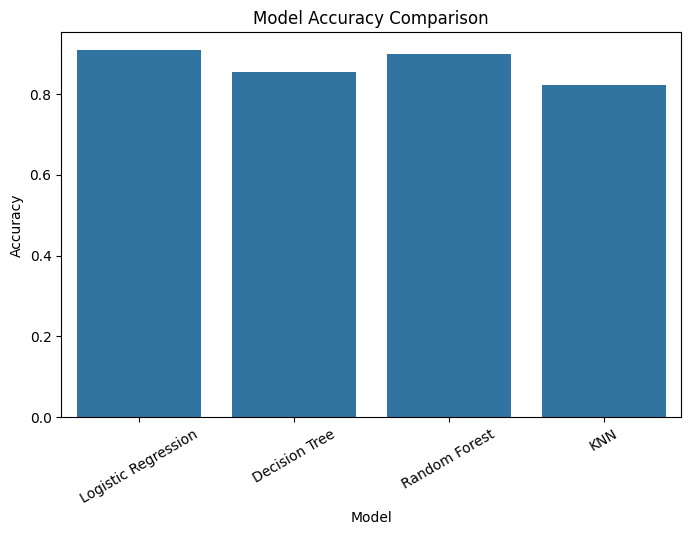

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="Accuracy", data=results)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)

plt.show()

So sánh toàn bộ 4 chỉ số:

In [44]:
results_melt = results.melt(id_vars="Model",
                            var_name="Metric",
                            value_name="Score")

results_melt

,Model,Metric,Score
0,Logistic Regression,Accuracy,0.907692
1,Decision Tree,Accuracy,0.853846
2,Random Forest,Accuracy,0.900000
3,KNN,Accuracy,0.823077
4,Logistic Regression,Precision,0.937500
5,Decision Tree,Precision,0.925234
6,Random Forest,Precision,0.929204
7,KNN,Precision,0.853659
8,Logistic Regression,Recall,0.954545
9,Decision Tree,Recall,0.900000


Biểu đồ so sánh toàn bộ metrics:

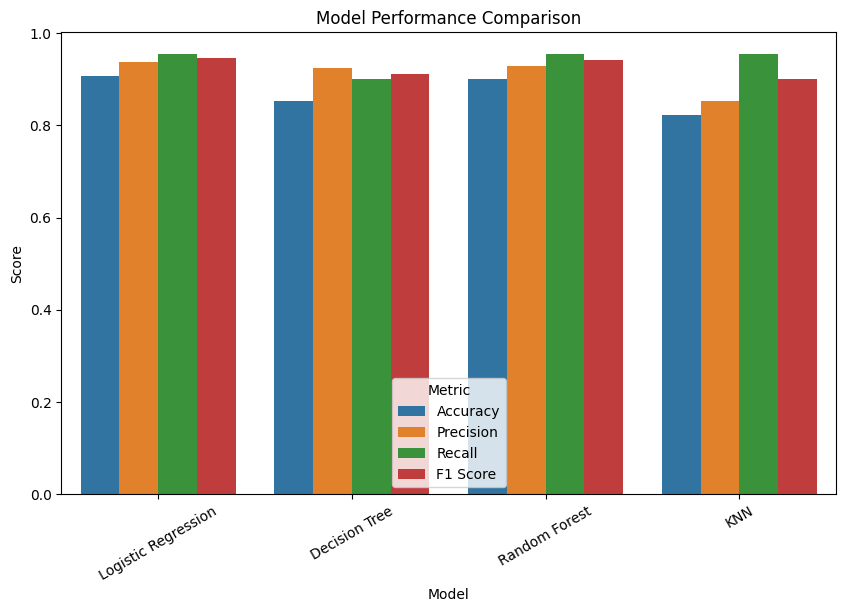

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(x="Model", y="Score", hue="Metric", data=results_melt)

plt.title("Model Performance Comparison")
plt.xticks(rotation=30)

plt.show()

# **Phase 7: Model Evaluation**

# ***7.1. Tạo Confusion Matrix cho từng mô hình***

In [46]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
print("log_model:", "OK" if 'log_model' in globals() else "MISSING")
print("tree_model:", "OK" if 'tree_model' in globals() else "MISSING")
print("rf_model:", "OK" if 'rf_model' in globals() else "MISSING")
print("knn_model:", "OK" if 'knn_model' in globals() else "MISSING")

print("y_pred_log:", "OK" if 'y_pred_log' in globals() else "MISSING")
print("y_pred_tree:", "OK" if 'y_pred_tree' in globals() else "MISSING")
print("y_pred_rf:", "OK" if 'y_pred_rf' in globals() else "MISSING")
print("y_pred_knn:", "OK" if 'y_pred_knn' in globals() else "MISSING")

log_model: OK
tree_model: OK
rf_model: OK
knn_model: OK
y_pred_log: OK
y_pred_tree: OK
y_pred_rf: OK
y_pred_knn: OK


In [48]:
y_true = y_test.squeeze()

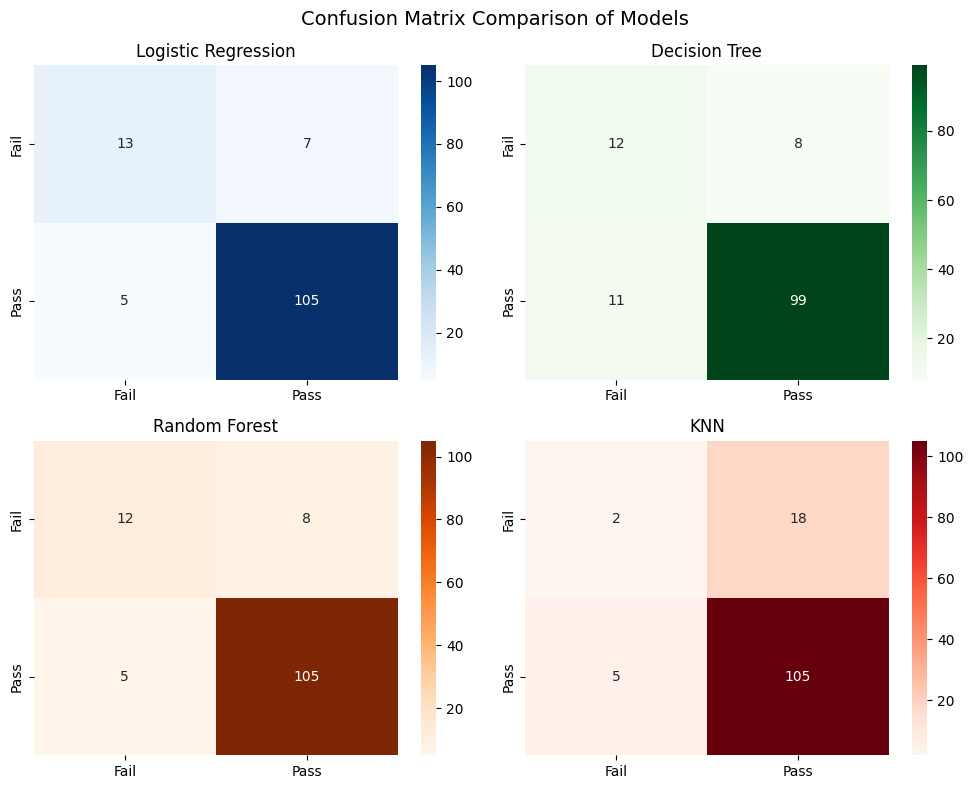

In [49]:
# tạo confusion matrix
cm_log = confusion_matrix(y_true, y_pred_log)
cm_tree = confusion_matrix(y_true, y_pred_tree)
cm_rf = confusion_matrix(y_true, y_pred_rf)
cm_knn = confusion_matrix(y_true, y_pred_knn)

# tạo figure chứa 4 biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Logistic Regression
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail','Pass'],
            yticklabels=['Fail','Pass'],
            ax=axes[0,0])
axes[0,0].set_title("Logistic Regression")

# Decision Tree
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fail','Pass'],
            yticklabels=['Fail','Pass'],
            ax=axes[0,1])
axes[0,1].set_title("Decision Tree")

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Fail','Pass'],
            yticklabels=['Fail','Pass'],
            ax=axes[1,0])
axes[1,0].set_title("Random Forest")

# KNN
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Fail','Pass'],
            yticklabels=['Fail','Pass'],
            ax=axes[1,1])
axes[1,1].set_title("KNN")

plt.suptitle("Confusion Matrix Comparison of Models", fontsize=14)

plt.tight_layout()

plt.show()

# ***7.2. Classification Report chi tiết***

In [50]:
print("=== Logistic Regression ===")
print(classification_report(y_true, y_pred_log))

print("=== Decision Tree ===")
print(classification_report(y_true, y_pred_tree))

print("=== Random Forest ===")
print(classification_report(y_true, y_pred_rf))

print("=== KNN ===")
print(classification_report(y_true, y_pred_knn))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.72      0.65      0.68        20
           1       0.94      0.95      0.95       110

    accuracy                           0.91       130
   macro avg       0.83      0.80      0.82       130
weighted avg       0.90      0.91      0.91       130

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.52      0.60      0.56        20
           1       0.93      0.90      0.91       110

    accuracy                           0.85       130
   macro avg       0.72      0.75      0.74       130
weighted avg       0.86      0.85      0.86       130

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        20
           1       0.93      0.95      0.94       110

    accuracy                           0.90       130
   macro avg       0.82      0.78      0.80       130
we

# ***7.3. Kết quả xây dựng và lựa chọn mô hình học máy***

Sau khi hoàn thành quá trình tiền xử lý và chuẩn hóa dữ liệu, bốn thuật toán học máy phổ biến đã được sử dụng để xây dựng các mô hình dự đoán kết quả học tập của sinh viên, bao gồm Logistic Regression, Decision Tree, Random Forest và K-Nearest Neighbors (KNN). Các mô hình được huấn luyện trên tập dữ liệu huấn luyện và đánh giá trên tập kiểm tra nhằm xác định mô hình có khả năng dự đoán tốt nhất cho bài toán phân loại Đạt (Pass) / Trượt (Fail).

Hiệu suất của các mô hình được đánh giá thông qua các chỉ số phổ biến trong bài toán phân loại gồm Accuracy, Precision, Recall và F1-score. Kết quả so sánh cho thấy Logistic Regression đạt hiệu suất tổng thể cao nhất với Accuracy khoảng 90.77%, đồng thời đạt Precision và F1-score cao nhất cho lớp “Pass”, cho thấy khả năng dự đoán ổn định và đáng tin cậy. Random Forest cũng cho thấy hiệu suất rất cạnh tranh với Accuracy khoảng 90.00%, chỉ thấp hơn Logistic Regression một mức rất nhỏ. Trong khi đó, Decision Tree đạt Accuracy khoảng 85.38%, thấp hơn đáng kể so với hai mô hình trên. KNN cho kết quả kém nhất với Accuracy chỉ khoảng 82.31%, cho thấy mô hình này không phù hợp với đặc điểm của bộ dữ liệu.

Phân tích chi tiết thông qua confusion matrix và classification report cho thấy sự khác biệt rõ ràng trong khả năng nhận diện các trường hợp sinh viên trượt môn. Logistic Regression dự đoán chính xác phần lớn các trường hợp của cả hai lớp với số lượng dự đoán sai tương đối thấp. Random Forest có hiệu suất tương tự nhưng có xu hướng bỏ sót nhiều trường hợp “Fail” hơn. Decision Tree thể hiện mức độ sai lệch cao hơn trong việc dự đoán cả hai lớp. Đặc biệt, KNN gặp khó khăn nghiêm trọng trong việc nhận diện lớp thiểu số “Fail”, chỉ phát hiện được một tỷ lệ rất nhỏ các sinh viên thực sự trượt môn, điều này làm giảm đáng kể tính hữu dụng của mô hình trong bối cảnh thực tế.

Dựa trên các kết quả đánh giá tổng thể, Logistic Regression được lựa chọn làm mô hình chính cho pipeline của đề tài. Lý do lựa chọn mô hình này không chỉ dựa trên Accuracy cao nhất, mà còn bởi sự cân bằng tốt giữa Precision và Recall cho cả hai lớp, đặc biệt là khả năng nhận diện tương đối tốt các trường hợp sinh viên có nguy cơ trượt môn. Ngoài ra, Logistic Regression là mô hình có cấu trúc đơn giản, dễ diễn giải và ổn định hơn so với các mô hình phức tạp, điều này rất phù hợp với mục tiêu của đề tài là xây dựng một hệ thống dự đoán có thể giải thích được và dễ áp dụng trong môi trường giáo dục.

Bên cạnh đó, Random Forest vẫn được xem là mô hình thay thế tiềm năng nhờ hiệu suất gần tương đương Logistic Regression. Tuy nhiên, do Logistic Regression cho kết quả ổn định hơn và có khả năng diễn giải tốt hơn, mô hình này được lựa chọn làm baseline model cho pipeline chính của hệ thống dự đoán nguy cơ trượt môn trong các giai đoạn tiếp theo của dự án.

# **Phase 8: Feature Importance Analysis**

Ý tưởng: Trong Logistic Regression, mỗi đặc trưng có một hệ số (coefficient):

* Hệ số dương → làm tăng khả năng Pass.

* Hệ số âm → làm tăng nguy cơ Fail.

* Giá trị |coefficient| càng lớn → ảnh hưởng càng mạnh.

Ta sẽ:

* Lấy các hệ số của Logistic Regression.

* Ghép với tên các feature.

* Sắp xếp theo độ quan trọng.

* Vẽ biểu đồ trực quan.

Lấy hệ số của Logistic Regression:

In [51]:
# lấy hệ số của Logistic Regression
coefficients = log_model.coef_[0]

# tên các feature
features = X_train.columns

# tạo dataframe
feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})

# độ quan trọng tuyệt đối
feature_importance["Importance"] = feature_importance["Coefficient"].abs()

# sắp xếp theo mức độ quan trọng
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Coefficient,Importance
14,G2,2.893321,2.893321
13,G1,2.037623,2.037623
15,school_MS,-0.831465,0.831465
25,Fjob_other,-0.752502,0.752502
26,Fjob_services,-0.710967,0.710967
0,age,0.702182,0.702182
20,Mjob_health,0.483467,0.483467
5,failures,-0.450700,0.450700
40,romantic_yes,-0.409986,0.409986
2,Fedu,-0.393414,0.393414


**Top 10 đặc trưng (features) quan trọng nhất:**

In [52]:
feature_importance.head(10)

,Feature,Coefficient,Importance
14,G2,2.893321,2.893321
13,G1,2.037623,2.037623
15,school_MS,-0.831465,0.831465
25,Fjob_other,-0.752502,0.752502
26,Fjob_services,-0.710967,0.710967
0,age,0.702182,0.702182
20,Mjob_health,0.483467,0.483467
5,failures,-0.450700,0.450700
40,romantic_yes,-0.409986,0.409986
2,Fedu,-0.393414,0.393414


Vẽ biểu đồ Feature Importance:

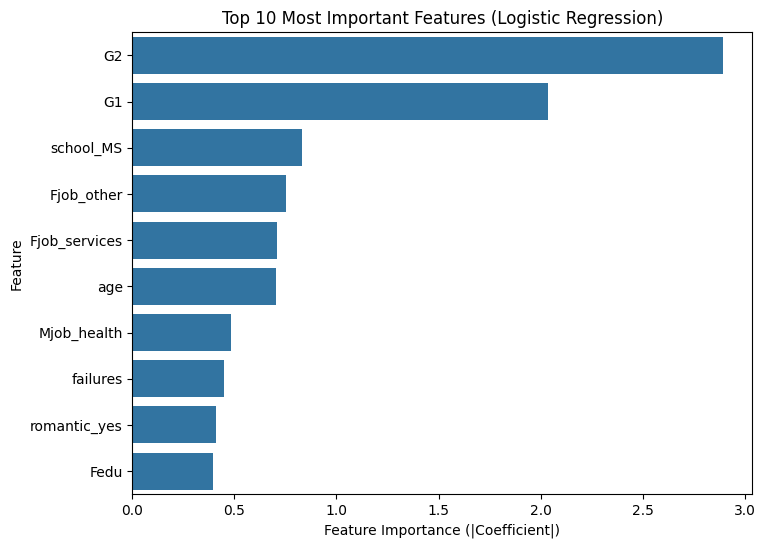

In [53]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Most Important Features (Logistic Regression)")
plt.xlabel("Feature Importance (|Coefficient|)")
plt.ylabel("Feature")

plt.show()

**Top các đặc trưng ảnh hưởng tích cực tới khả năng PASS của sinh viên:**

In [54]:
feature_importance.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient,Importance
14,G2,2.893321,2.893321
13,G1,2.037623,2.037623
0,age,0.702182,0.702182
20,Mjob_health,0.483467,0.483467
30,reason_reputation,0.375284,0.375284
38,higher_yes,0.317382,0.317382
3,traveltime,0.236561,0.236561
1,Medu,0.152697,0.152697
28,reason_home,0.143528,0.143528
23,Mjob_teacher,0.127106,0.127106


**Top các đặc trưng ảnh hưởng tiêu cực tới khả năng PASS của sinh viên:**

In [55]:
feature_importance.sort_values(by="Coefficient").head(10)

,Feature,Coefficient,Importance
15,school_MS,-0.831465,0.831465
25,Fjob_other,-0.752502,0.752502
26,Fjob_services,-0.710967,0.710967
5,failures,-0.450700,0.450700
40,romantic_yes,-0.409986,0.409986
2,Fedu,-0.393414,0.393414
31,guardian_mother,-0.355786,0.355786
12,absences,-0.312517,0.312517
39,internet_yes,-0.279719,0.279719
11,health,-0.245715,0.245715


# **Phase 9: Cải thiện mô hình ML**

In [56]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [57]:
y_train_1d = y_train.squeeze()
y_test_1d = y_test.squeeze()

# ***9.1. Tối ưu Logistic Regression bằng Grid Search***

In [58]:
param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

grid_log = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid_log,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_log.fit(X_train_scaled, y_train_1d)

best_log_model = grid_log.best_estimator_
y_pred_best_log = best_log_model.predict(X_test_scaled)

print("Best Parameters (Logistic Regression):", grid_log.best_params_)
print("Best CV Score:", grid_log.best_score_)
print("Test Accuracy:", accuracy_score(y_test_1d, y_pred_best_log))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_best_log))
print("\nClassification Report:")
print(classification_report(y_test_1d, y_pred_best_log))

Best Parameters (Logistic Regression): {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.9534081990220891
Test Accuracy: 0.9

Confusion Matrix:
[[ 11   9]
 [  4 106]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.55      0.63        20
           1       0.92      0.96      0.94       110

    accuracy                           0.90       130
   macro avg       0.83      0.76      0.79       130
weighted avg       0.89      0.90      0.89       130



# ***9.2. Tối ưu Random Forest bằng Grid Search***

In [59]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train_1d)

best_rf_model = grid_rf.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test_scaled)

print("Best Parameters (Random Forest):", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)
print("Test Accuracy:", accuracy_score(y_test_1d, y_pred_best_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_best_rf))
print("\nClassification Report:")
print(classification_report(y_test_1d, y_pred_best_rf))

Best Parameters (Random Forest): {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9665438934502564
Test Accuracy: 0.9

Confusion Matrix:
[[ 12   8]
 [  5 105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        20
           1       0.93      0.95      0.94       110

    accuracy                           0.90       130
   macro avg       0.82      0.78      0.80       130
weighted avg       0.89      0.90      0.90       130



# **9.3. XGBoost**

In [60]:
from xgboost import XGBClassifier

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train_scaled, y_train_1d)

best_xgb_model = grid_xgb.best_estimator_
y_pred_best_xgb = best_xgb_model.predict(X_test_scaled)

print("Best Parameters (XGBoost):", grid_xgb.best_params_)
print("Best CV Score:", grid_xgb.best_score_)
print("Test Accuracy:", accuracy_score(y_test_1d, y_pred_best_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_best_xgb))
print("\nClassification Report:")
print(classification_report(y_test_1d, y_pred_best_xgb))

Best Parameters (XGBoost): {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best CV Score: 0.9685556920796173
Test Accuracy: 0.9

Confusion Matrix:
[[ 13   7]
 [  6 104]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.65      0.67        20
           1       0.94      0.95      0.94       110

    accuracy                           0.90       130
   macro avg       0.81      0.80      0.80       130
weighted avg       0.90      0.90      0.90       130



# ***9.4. Kết quả tối ưu hóa và biểu đồ so sánh***

**Tổng hợp kết quả sau khi tối ưu hóa mô hình:**

In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score

results_optimized = pd.DataFrame({
    'Model': ['Optimized Logistic Regression', 'Optimized Random Forest', 'Optimized XGBoost'],
    'Accuracy': [
        accuracy_score(y_test_1d, y_pred_best_log),
        accuracy_score(y_test_1d, y_pred_best_rf),
        accuracy_score(y_test_1d, y_pred_best_xgb)
    ],
    'Precision': [
        precision_score(y_test_1d, y_pred_best_log),
        precision_score(y_test_1d, y_pred_best_rf),
        precision_score(y_test_1d, y_pred_best_xgb)
    ],
    'Recall': [
        recall_score(y_test_1d, y_pred_best_log),
        recall_score(y_test_1d, y_pred_best_rf),
        recall_score(y_test_1d, y_pred_best_xgb)
    ],
    'F1 Score': [
        f1_score(y_test_1d, y_pred_best_log),
        f1_score(y_test_1d, y_pred_best_rf),
        f1_score(y_test_1d, y_pred_best_xgb)
    ]
})

results_optimized

,Model,Accuracy,Precision,Recall,F1 Score
0,Optimized Logistic Regression,0.9,0.921739,0.963636,0.942222
1,Optimized Random Forest,0.9,0.929204,0.954545,0.941704
2,Optimized XGBoost,0.9,0.936937,0.945455,0.941176


**Biểu đồ so sánh:**

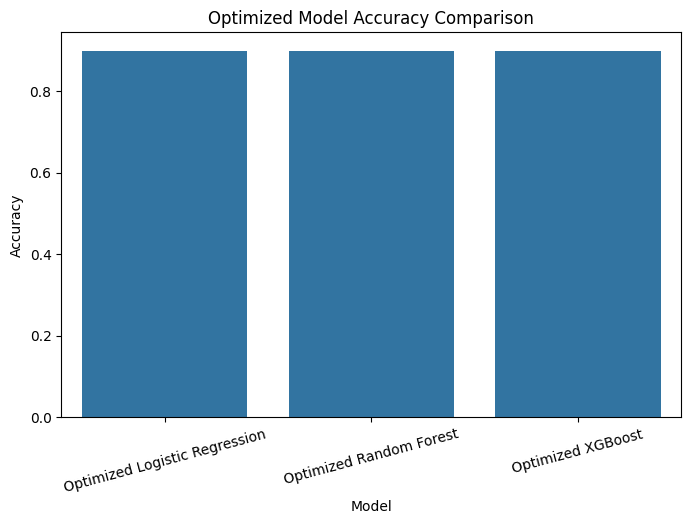

In [62]:
#Acc:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results_optimized)
plt.title("Optimized Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

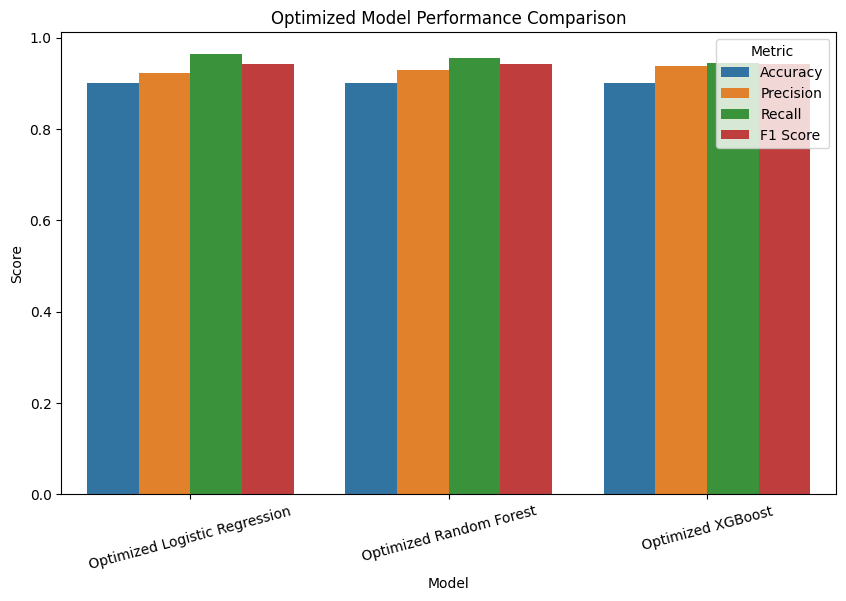

In [63]:

#Toàn bộ các metrics:
results_optimized_melt = results_optimized.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_optimized_melt)
plt.title("Optimized Model Performance Comparison")
plt.xticks(rotation=15)
plt.show()

Khi thực hiện tối ưu hóa siêu tham số bằng Grid Search, các mô hình Logistic Regression, Random Forest và XGBoost đều đạt mức Accuracy xấp xỉ 0.90, tức là không có cải thiện đáng kể so với mô hình Logistic Regression cơ bản. Đặc biệt, phiên bản Logistic Regression sau tối ưu còn làm giảm Recall của lớp “Fail”, cho thấy mô hình bỏ sót nhiều trường hợp sinh viên trượt môn hơn. Do đó, việc tối ưu hóa không mang lại lợi ích rõ rệt đối với bài toán hiện tại.

Ngoài hiệu suất dự đoán ổn định, Logistic Regression còn có ưu điểm quan trọng là tính đơn giản và khả năng giải thích cao. Các hệ số của mô hình cho phép phân tích trực tiếp mức độ ảnh hưởng của từng đặc trưng đến kết quả dự đoán, giúp xác định các yếu tố quan trọng như điểm giữa kỳ, số lần trượt môn trước đây hoặc số ngày vắng học. Điều này đặc biệt phù hợp với bối cảnh giáo dục, nơi việc hiểu và giải thích nguyên nhân ảnh hưởng đến kết quả học tập của sinh viên có ý nghĩa quan trọng đối với việc xây dựng các chiến lược hỗ trợ và can thiệp sớm.

Vì những lý do trên, Logistic Regression cơ bản được lựa chọn làm mô hình chính của pipeline dự đoán, trong khi các mô hình phức tạp hơn như Random Forest và XGBoost được xem là các phương án tham khảo để so sánh hiệu suất. Lựa chọn này đảm bảo sự cân bằng giữa hiệu suất dự đoán, khả năng phát hiện sinh viên có nguy cơ trượt môn và tính minh bạch trong giải thích mô hình.

# **Phase 10: Phân cụm sinh viên (Clustering Analysis)**

In [64]:
# tạo bản sao dữ liệu cho phase 10
df_cluster = df.copy()

# kiểm tra nhanh
df_cluster.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,1


# ***10.1. Chọn các đặc trưng dùng để phân cụm***

In [65]:
cluster_features = [
    "age", "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health",
    "absences", "G1", "G2",
    "schoolsup", "famsup", "paid", "activities", "internet", "romantic"
]

df_cluster_selected = df_cluster[cluster_features].copy()

df_cluster_selected.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,health,absences,G1,G2,schoolsup,famsup,paid,activities,internet,romantic
0,18,4,4,2,2,0,4,3,4,1,...,3,4,0,11,yes,no,no,no,no,no
1,17,1,1,1,2,0,5,3,3,1,...,3,2,9,11,no,yes,no,no,yes,no
2,15,1,1,1,2,0,4,3,2,2,...,3,6,12,13,yes,no,no,no,yes,no
3,15,4,2,1,3,0,3,2,2,1,...,5,0,14,14,no,yes,no,yes,yes,yes
4,16,3,3,1,2,0,4,3,2,1,...,5,0,11,13,no,yes,no,no,no,no


Trong đó:

* **G1, G2** giúp phản ánh năng lực học tập trước kỳ cuối.

* **studytime, failures, absences** phản ánh hành vi học tập.

* **goout, Dalc, Walc, freetime** phản ánh lối sống.

* **Medu, Fedu, internet, schoolsup, famsup** phản ánh bối cảnh hỗ trợ.

# ***10.2. Mã hóa biến phân loại & chuẩn hóa dữ liệu cho clustering***

In [66]:
df_cluster_encoded = pd.get_dummies(df_cluster_selected, drop_first=True)
df_cluster_encoded = df_cluster_encoded.astype(int)

df_cluster_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,health,absences,G1,G2,schoolsup_yes,famsup_yes,paid_yes,activities_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,3,4,0,11,1,0,0,0,0,0
1,17,1,1,1,2,0,5,3,3,1,...,3,2,9,11,0,1,0,0,1,0
2,15,1,1,1,2,0,4,3,2,2,...,3,6,12,13,1,0,0,0,1,0
3,15,4,2,1,3,0,3,2,2,1,...,5,0,14,14,0,1,0,1,1,1
4,16,3,3,1,2,0,4,3,2,1,...,5,0,11,13,0,1,0,0,0,0


In [67]:
from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(df_cluster_encoded)

# ***10.3. Xác định số cụm k bằng Elbow Method***

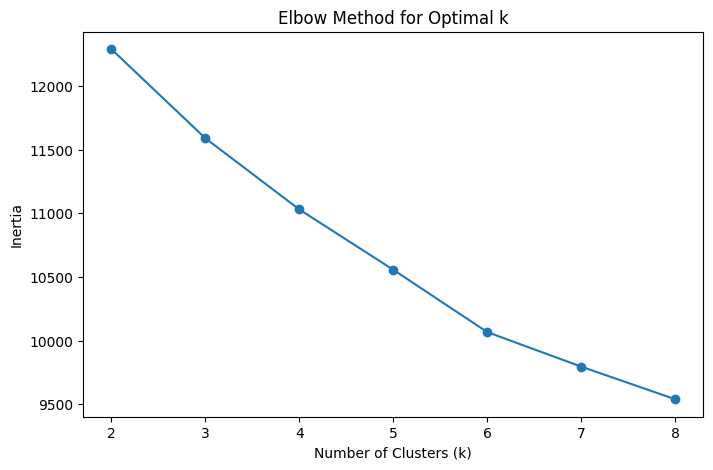

In [68]:
from sklearn.cluster import KMeans

inertia_values = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_values, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.show()

**Đánh giá thêm bằng Silhouette Score:**

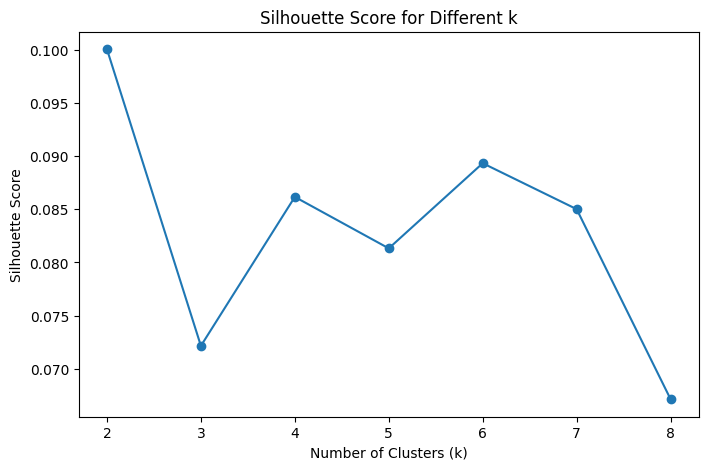

k = 2: silhouette score = 0.1001
k = 3: silhouette score = 0.0721
k = 4: silhouette score = 0.0862
k = 5: silhouette score = 0.0813
k = 6: silhouette score = 0.0893
k = 7: silhouette score = 0.0850
k = 8: silhouette score = 0.0671


In [69]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score for Different k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.show()

for k, score in zip(k_values, silhouette_scores):
    print(f"k = {k}: silhouette score = {score:.4f}")

Để xác định số cụm tối ưu cho thuật toán K-Means, hai phương pháp Elbow Method và Silhouette Score được sử dụng. Kết quả từ Elbow Method cho thấy giá trị inertia giảm mạnh khi số cụm tăng từ 2 đến khoảng 6, sau đó tốc độ giảm bắt đầu chậm lại, cho thấy điểm khuỷu tay (elbow point) nằm khoảng k = 6. Đồng thời, phân tích Silhouette Score cũng cho thấy giá trị cao thứ hai tại k = 6 (0.0893), cho thấy mức độ tách biệt giữa các cụm khá tốt. Do đó, k = 6 được lựa chọn làm số cụm tối ưu để thực hiện phân cụm sinh viên bằng thuật toán K-Means.

Ngoài ra, Silhouette score không quá cao cho thấy dữ liệu không tạo thành các cụm tách biệt hoàn toàn, mà tồn tại các vùng chuyển tiếp giữa các nhóm sinh viên. Điều này phản ánh thực tế rằng hành vi học tập của sinh viên thường biến đổi liên tục thay vì phân chia thành các nhóm rời rạc.

# ***10.4. Huấn luyện K-Means với số cụm tối ưu (k = 6)***

In [70]:
k_optimal = 6

from sklearn.cluster import KMeans

kmeans_model = KMeans(
    n_clusters=k_optimal,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(X_cluster_scaled)

# thêm nhãn cluster vào dataframe
df_cluster["cluster"] = cluster_labels

df_cluster[["G1", "G2", "G3", "pass", "cluster"]].head()

,G1,G2,G3,pass,cluster
0,0,11,11,1,3
1,9,11,11,1,2
2,12,13,12,1,3
3,14,14,14,1,1
4,11,13,13,1,1


Số lượng sinh viên trong từng cụm:

In [71]:
df_cluster["cluster"].value_counts().sort_index()

,count
cluster,
0,100
1,195
2,195
3,55
4,65
5,39


# ***10.5. Trực quan hóa các cụm bằng PCA***

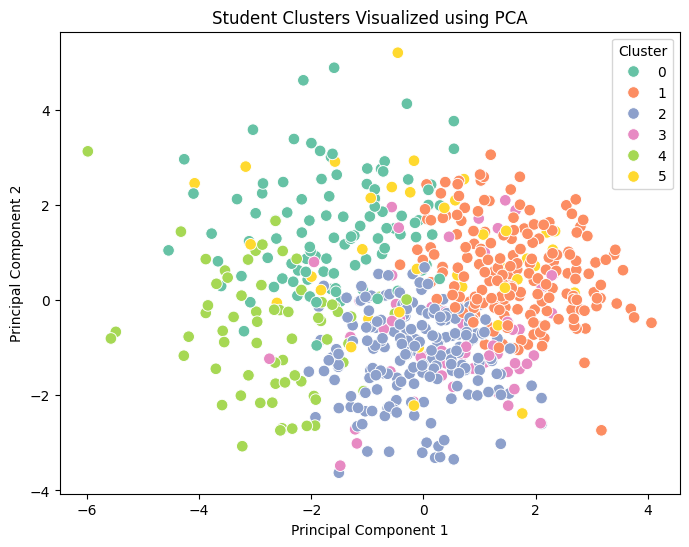

In [72]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_cluster_pca = pca.fit_transform(X_cluster_scaled)

pca_df = pd.DataFrame(X_cluster_pca, columns=["PC1", "PC2"])

pca_df["cluster"] = cluster_labels

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=70
)

plt.title("Student Clusters Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

# ***10.6. Phân tích features của từng cụm sinh viên***

In [73]:
cluster_profile = df_cluster.groupby("cluster")[[
    "studytime",
    "failures",
    "absences",
    "goout",
    "Dalc",
    "Walc",
    "G1",
    "G2",
    "G3",
    "pass"
]].mean().round(2)

cluster_profile

,studytime,failures,absences,goout,Dalc,Walc,G1,G2,G3,pass
cluster,,,,,,,,,,
0,1.54,0.16,6.19,4.12,2.81,4.00,9.87,10.08,10.37,0.78
1,2.18,0.01,3.37,3.10,1.20,2.03,13.57,13.83,14.35,0.98
2,1.93,0.03,2.64,2.87,1.16,1.78,11.35,11.46,11.95,0.90
3,2.24,0.11,2.82,3.00,1.33,1.85,11.18,11.44,11.44,0.93
4,1.54,1.54,4.82,3.11,1.46,2.14,7.97,7.77,7.60,0.35
5,1.92,0.38,3.00,3.15,1.69,2.46,10.72,11.18,11.21,0.77


# ***10.6. Phân tích tỷ lệ PASS/FAIL của từng cụm sinh viên***

In [74]:
cluster_pass_rate = (
    df_cluster.groupby("cluster")["pass"]
    .value_counts(normalize=True)
    .rename("ratio")
    .reset_index()
)

cluster_pass_rate

,cluster,pass,ratio
0,0,1,0.780000
1,0,0,0.220000
2,1,1,0.979487
3,1,0,0.020513
4,2,1,0.902564
5,2,0,0.097436
6,3,1,0.927273
7,3,0,0.072727
8,4,0,0.646154
9,4,1,0.353846


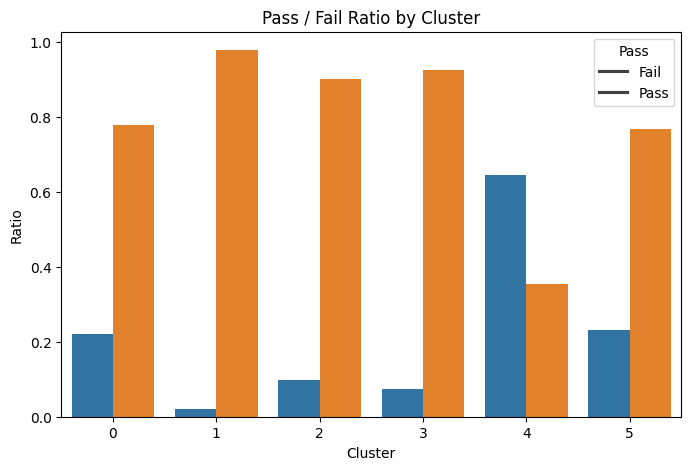

In [75]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cluster_pass_rate,
    x="cluster",
    y="ratio",
    hue="pass"
)

plt.title("Pass / Fail Ratio by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Ratio")

plt.legend(title="Pass", labels=["Fail", "Pass"])

plt.show()

# ***10.7. Phân tích đặc điểm tổng hợp từng cụm sinh viên***

In [76]:
cluster_summary = df_cluster.groupby("cluster").agg({
    "age": "mean",
    "Medu": "mean",
    "Fedu": "mean",
    "studytime": "mean",
    "failures": "mean",
    "absences": "mean",
    "goout": "mean",
    "Dalc": "mean",
    "Walc": "mean",
    "G1": "mean",
    "G2": "mean",
    "G3": "mean",
    "pass": "mean"
}).round(2)

cluster_summary

,age,Medu,Fedu,studytime,failures,absences,goout,Dalc,Walc,G1,G2,G3,pass
cluster,,,,,,,,,,,,,
0,16.78,2.43,2.28,1.54,0.16,6.19,4.12,2.81,4.00,9.87,10.08,10.37,0.78
1,16.61,3.48,3.12,2.18,0.01,3.37,3.10,1.20,2.03,13.57,13.83,14.35,0.98
2,16.62,1.77,1.61,1.93,0.03,2.64,2.87,1.16,1.78,11.35,11.46,11.95,0.90
3,16.07,2.47,2.47,2.24,0.11,2.82,3.00,1.33,1.85,11.18,11.44,11.44,0.93
4,18.05,1.71,1.62,1.54,1.54,4.82,3.11,1.46,2.14,7.97,7.77,7.60,0.35
5,16.72,3.03,2.72,1.92,0.38,3.00,3.15,1.69,2.46,10.72,11.18,11.21,0.77


# ***10.8. Xác định chân dung từng cụm sinh viên***


Sau khi phân tích các giá trị trung bình của từng cụm trong bảng cluster_summary, mỗi cụm được gán một tên mô tả nhằm phản ánh đặc điểm học tập và hành vi nổi bật của nhóm sinh viên trong cụm đó. Việc đặt tên này không phải là kết quả trực tiếp của thuật toán K-Means mà là bước diễn giải (interpretation) dựa trên các đặc trưng trung bình của từng nhóm. Cụ thể, các chỉ số như thời gian học tập (studytime), số lần trượt môn trước đó (failures), số buổi vắng học (absences), mức độ đi chơi (goout), mức tiêu thụ rượu bia (Dalc, Walc), điểm số học tập (G1, G2, G3) và tỷ lệ qua môn (pass) được sử dụng để xác định đặc điểm nổi bật của từng cluster.

* **Cluster 1** được đặt tên là **High-performing students** vì nhóm sinh viên này có điểm trung bình cao nhất ở cả ba kỳ học (G1, G2, G3), thời gian học tập tương đối cao, gần như không có tiền sử trượt môn và tỷ lệ qua môn lên tới khoảng 98%. Những đặc điểm này cho thấy đây là nhóm sinh viên có kết quả học tập tốt và ổn định nhất trong dataset.

* **Cluster 4** được đặt tên là **At-risk students** do đây là nhóm có điểm trung bình thấp nhất, số lần trượt môn trước đó cao nhất và tỷ lệ qua môn chỉ khoảng 35%. Điều này cho thấy phần lớn sinh viên trong cụm này có nguy cơ trượt môn cao và cần được quan tâm hoặc hỗ trợ học tập nhiều hơn.

* **Cluster 0** được đặt tên là **Social-active students** vì các chỉ số về hoạt động xã hội của nhóm này cao hơn các cụm khác, thể hiện qua mức độ đi chơi (goout) cao, mức tiêu thụ rượu bia (Dalc và Walc) cao và số buổi vắng học nhiều. Mặc dù điểm trung bình của nhóm này không quá thấp, kết quả học tập vẫn chỉ ở mức trung bình, cho thấy các yếu tố lối sống có thể ảnh hưởng đến hiệu quả học tập của sinh viên.

* **Cluster 2** được đặt tên là **Stable students** vì các chỉ số của nhóm này khá cân bằng: số lần trượt môn thấp, điểm trung bình ở mức khá và tỷ lệ qua môn cao (khoảng 90%). Nhóm sinh viên này thể hiện mô hình học tập ổn định, không có các hành vi học tập hoặc lối sống cực đoan.

* **Cluster 3** được đặt tên là **Hardworking students** vì nhóm này có thời gian học tập tương đối cao và tỷ lệ qua môn khoảng 93%. Mặc dù điểm số không cao bằng cluster 1, sinh viên trong nhóm này có xu hướng chăm học và duy trì kết quả học tập khá tốt.

* **Cluster 5** được đặt tên là **Moderate students** vì nhóm này có các chỉ số học tập ở mức trung bình, với điểm cuối kỳ khoảng 11.21 và tỷ lệ qua môn khoảng 77%. Nhóm sinh viên này không có đặc điểm nổi bật rõ rệt về hành vi học tập hoặc lối sống, thể hiện một nhóm sinh viên có kết quả học tập ở mức trung bình.

In [77]:
cluster_name_map = {
    0: "Social-active students",
    1: "High-performing students",
    2: "Stable students",
    3: "Hardworking students",
    4: "At-risk students",
    5: "Moderate students"
}

df_cluster["cluster_name"] = df_cluster["cluster"].map(cluster_name_map)

df_cluster[["cluster", "cluster_name"]].head()

,cluster,cluster_name
0,3,Hardworking students
1,2,Stable students
2,3,Hardworking students
3,1,High-performing students
4,1,High-performing students


# **Phase 11: Khai phá luật kết hợp (Association Rule Mining)**

In [78]:
df_assoc = df.copy()

assoc_features = ["studytime", "failures", "absences", "goout", "G1", "G2", "pass"]
df_assoc = df_assoc[assoc_features].copy()

df_assoc.head()

,studytime,failures,absences,goout,G1,G2,pass
0,2,0,4,4,0,11,1
1,2,0,2,3,9,11,1
2,2,0,6,2,12,13,1
3,3,0,0,2,14,14,1
4,2,0,0,2,11,13,1


**Rời rạc hóa các biến số thành mức Low/Medium/High:**

In [79]:
import pandas as pd
import numpy as np

def safe_qcut(series, q=3, labels=None):
    if labels is None:
        labels = ["low", "medium", "high"]
    try:
        return pd.qcut(series, q=q, labels=labels, duplicates="drop")
    except:
        return pd.cut(series, bins=q, labels=labels, include_lowest=True)

df_assoc["G1_level"] = safe_qcut(df_assoc["G1"], q=3, labels=["low", "medium", "high"])
df_assoc["G2_level"] = safe_qcut(df_assoc["G2"], q=3, labels=["low", "medium", "high"])
df_assoc["absences_level"] = safe_qcut(df_assoc["absences"], q=3, labels=["low", "medium", "high"])

df_assoc["studytime_level"] = df_assoc["studytime"].map({
    1: "low",
    2: "medium",
    3: "high",
    4: "high"
})

df_assoc["failures_level"] = df_assoc["failures"].apply(
    lambda x: "none" if x == 0 else ("low" if x == 1 else "high")
)

df_assoc["goout_level"] = df_assoc["goout"].apply(
    lambda x: "low" if x <= 2 else ("medium" if x == 3 else "high")
)

df_assoc["pass_label"] = df_assoc["pass"].map({1: "pass", 0: "fail"})

df_assoc.head()

,studytime,failures,absences,goout,G1,G2,pass,G1_level,G2_level,absences_level,studytime_level,failures_level,goout_level,pass_label
0,2,0,4,4,0,11,1,low,medium,low,medium,none,high,pass
1,2,0,2,3,9,11,1,low,medium,low,medium,none,medium,pass
2,2,0,6,2,12,13,1,medium,medium,low,medium,none,low,pass
3,3,0,0,2,14,14,1,high,high,low,high,none,low,pass
4,2,0,0,2,11,13,1,medium,medium,low,medium,none,low,pass


**Tạo transaction dataset cho Apriori:**

In [80]:
transaction_df = pd.DataFrame({
    "studytime": "studytime_" + df_assoc["studytime_level"].astype(str),
    "failures": "failures_" + df_assoc["failures_level"].astype(str),
    "absences": "absences_" + df_assoc["absences_level"].astype(str),
    "goout": "goout_" + df_assoc["goout_level"].astype(str),
    "G1": "G1_" + df_assoc["G1_level"].astype(str),
    "G2": "G2_" + df_assoc["G2_level"].astype(str),
    "pass_result": "result_" + df_assoc["pass_label"].astype(str)
})

transaction_df.head()

,studytime,failures,absences,goout,G1,G2,pass_result
0,studytime_medium,failures_none,absences_low,goout_high,G1_low,G2_medium,result_pass
1,studytime_medium,failures_none,absences_low,goout_medium,G1_low,G2_medium,result_pass
2,studytime_medium,failures_none,absences_low,goout_low,G1_medium,G2_medium,result_pass
3,studytime_high,failures_none,absences_low,goout_low,G1_high,G2_high,result_pass
4,studytime_medium,failures_none,absences_low,goout_low,G1_medium,G2_medium,result_pass


**One-hot encode về dạng boolean cho Apriori:**

In [81]:
basket = pd.get_dummies(transaction_df).astype(bool)

print("Transaction matrix shape:", basket.shape)
basket.head()

Transaction matrix shape: (649, 20)


,studytime_studytime_high,studytime_studytime_low,studytime_studytime_medium,failures_failures_high,failures_failures_low,failures_failures_none,absences_absences_high,absences_absences_low,absences_absences_medium,goout_goout_high,goout_goout_low,goout_goout_medium,G1_G1_high,G1_G1_low,G1_G1_medium,G2_G2_high,G2_G2_low,G2_G2_medium,pass_result_result_fail,pass_result_result_pass
0,False,False,True,False,False,True,False,True,False,True,False,False,False,True,False,False,False,True,False,True
1,False,False,True,False,False,True,False,True,False,False,False,True,False,True,False,False,False,True,False,True
2,False,False,True,False,False,True,False,True,False,False,True,False,False,False,True,False,False,True,False,True
3,True,False,False,False,False,True,False,True,False,False,True,False,True,False,False,True,False,False,False,True
4,False,False,True,False,False,True,False,True,False,False,True,False,False,False,True,False,False,True,False,True


**Apriori với ngưỡng an toàn:**

In [82]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    basket,
    min_support=0.08,
    use_colnames=True,
    max_len=3
)

frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)
frequent_itemsets.head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
5,0.924499,(absences_absences_low)
4,0.845917,(failures_failures_none)
16,0.845917,(pass_result_result_pass)
47,0.798151,"(absences_absences_low, failures_failures_none)"
68,0.788906,"(absences_absences_low, pass_result_result_pass)"
57,0.767334,"(pass_result_result_pass, failures_failures_none)"
172,0.727273,"(absences_absences_low, pass_result_result_pas..."
2,0.469954,(studytime_studytime_medium)
33,0.432974,"(absences_absences_low, studytime_studytime_me..."
14,0.414484,(G2_G2_medium)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Sinh luật:**

In [83]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules = rules.sort_values(by=["lift", "confidence", "support"], ascending=False)
rules.head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
182,"(absences_absences_low, G1_G1_high)",(G2_G2_high),0.228043,0.234206,0.187982,0.824324,3.519648,1.0,0.134572,4.359132,0.927358,0.685393,0.770597,0.813478
307,"(G1_G1_high, studytime_studytime_medium)",(G2_G2_high),0.114022,0.234206,0.093991,0.824324,3.519648,1.0,0.067286,4.359132,0.808011,0.369697,0.770597,0.612820
184,(G2_G2_high),"(absences_absences_low, G1_G1_high)",0.234206,0.228043,0.187982,0.802632,3.519648,1.0,0.134572,3.911248,0.934822,0.685393,0.744327,0.813478
178,"(failures_failures_none, G1_G1_high)",(G2_G2_high),0.229584,0.234206,0.187982,0.818792,3.496026,1.0,0.134211,4.226046,0.926721,0.681564,0.763372,0.810712
181,"(absences_absences_low, G2_G2_high)",(G1_G1_high),0.229584,0.234206,0.187982,0.818792,3.496026,1.0,0.134211,4.226046,0.926721,0.681564,0.763372,0.810712
179,(G2_G2_high),"(failures_failures_none, G1_G1_high)",0.234206,0.229584,0.187982,0.802632,3.496026,1.0,0.134211,3.903441,0.932315,0.681564,0.743816,0.810712
185,(G1_G1_high),"(absences_absences_low, G2_G2_high)",0.234206,0.229584,0.187982,0.802632,3.496026,1.0,0.134211,3.903441,0.932315,0.681564,0.743816,0.810712
163,"(G2_G2_high, pass_result_result_pass)",(G1_G1_high),0.234206,0.234206,0.191063,0.815789,3.483206,1.0,0.136211,4.157165,0.930940,0.688889,0.759451,0.815789
165,"(pass_result_result_pass, G1_G1_high)",(G2_G2_high),0.234206,0.234206,0.191063,0.815789,3.483206,1.0,0.136211,4.157165,0.930940,0.688889,0.759451,0.815789
166,(G2_G2_high),"(pass_result_result_pass, G1_G1_high)",0.234206,0.234206,0.191063,0.815789,3.483206,1.0,0.136211,4.157165,0.930940,0.688889,0.759451,0.815789


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [84]:
def format_itemset(itemset):
    return ", ".join(sorted(list(itemset)))

rules_display = rules.copy()
rules_display["antecedents"] = rules_display["antecedents"].apply(format_itemset)
rules_display["consequents"] = rules_display["consequents"].apply(format_itemset)

rules_display = rules_display[[
    "antecedents", "consequents", "support", "confidence", "lift"
]].copy()

rules_display["support"] = rules_display["support"].round(4)
rules_display["confidence"] = rules_display["confidence"].round(4)
rules_display["lift"] = rules_display["lift"].round(4)

rules_display.head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
182,"G1_G1_high, absences_absences_low",G2_G2_high,0.1880,0.8243,3.5196
307,"G1_G1_high, studytime_studytime_medium",G2_G2_high,0.0940,0.8243,3.5196
184,G2_G2_high,"G1_G1_high, absences_absences_low",0.1880,0.8026,3.5196
178,"G1_G1_high, failures_failures_none",G2_G2_high,0.1880,0.8188,3.4960
181,"G2_G2_high, absences_absences_low",G1_G1_high,0.1880,0.8188,3.4960
179,G2_G2_high,"G1_G1_high, failures_failures_none",0.1880,0.8026,3.4960
185,G1_G1_high,"G2_G2_high, absences_absences_low",0.1880,0.8026,3.4960
163,"G2_G2_high, pass_result_result_pass",G1_G1_high,0.1911,0.8158,3.4832
165,"G1_G1_high, pass_result_result_pass",G2_G2_high,0.1911,0.8158,3.4832
166,G2_G2_high,"G1_G1_high, pass_result_result_pass",0.1911,0.8158,3.4832


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Luật dẫn đến kết quả FAIL:**

In [85]:
rules_fail = rules[
    rules["consequents"].apply(lambda x: "result_fail" in ",".join(list(x)))
].copy()

rules_fail["antecedents"] = rules_fail["antecedents"].apply(format_itemset)
rules_fail["consequents"] = rules_fail["consequents"].apply(format_itemset)

rules_fail = rules_fail[[
    "antecedents", "consequents", "support", "confidence", "lift"
]].sort_values(by=["lift", "confidence", "support"], ascending=False)

rules_fail["support"] = rules_fail["support"].round(4)
rules_fail["confidence"] = rules_fail["confidence"].round(4)
rules_fail["lift"] = rules_fail["lift"].round(4)

rules_fail.head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
225,"G1_G1_low, G2_G2_low",pass_result_result_fail,0.1495,0.5052,3.2788


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Luật dẫn đến kết quả PASS:**

In [86]:
rules_pass = rules[
    rules["consequents"].apply(lambda x: "result_pass" in ",".join(list(x)))
].copy()

rules_pass["antecedents"] = rules_pass["antecedents"].apply(format_itemset)
rules_pass["consequents"] = rules_pass["consequents"].apply(format_itemset)

rules_pass = rules_pass[[
    "antecedents", "consequents", "support", "confidence", "lift"
]].sort_values(by=["lift", "confidence", "support"], ascending=False)

rules_pass["support"] = rules_pass["support"].round(4)
rules_pass["confidence"] = rules_pass["confidence"].round(4)
rules_pass["lift"] = rules_pass["lift"].round(4)

rules_pass.head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
166,G2_G2_high,"G1_G1_high, pass_result_result_pass",0.1911,0.8158,3.4832
167,G1_G1_high,"G2_G2_high, pass_result_result_pass",0.1911,0.8158,3.4832
72,G2_G2_medium,"G1_G1_medium, pass_result_result_pass",0.2773,0.6691,1.7871
71,G1_G1_medium,"G2_G2_medium, pass_result_result_pass",0.2773,0.7347,1.7858
123,G2_G2_high,"failures_failures_none, pass_result_result_pass",0.2311,0.9868,1.2861
131,G1_G1_high,"failures_failures_none, pass_result_result_pass",0.2296,0.9803,1.2775
41,G1_G1_medium,"failures_failures_none, pass_result_result_pass",0.3606,0.9551,1.2447
135,G2_G2_high,"absences_absences_low, pass_result_result_pass",0.2296,0.9803,1.2426
142,G1_G1_high,"absences_absences_low, pass_result_result_pass",0.2280,0.9737,1.2342
174,G1_G1_medium,"pass_result_result_pass, studytime_studytime_m...",0.1895,0.5020,1.2342


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Scatter support/confidence của toàn bộ luật:**

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

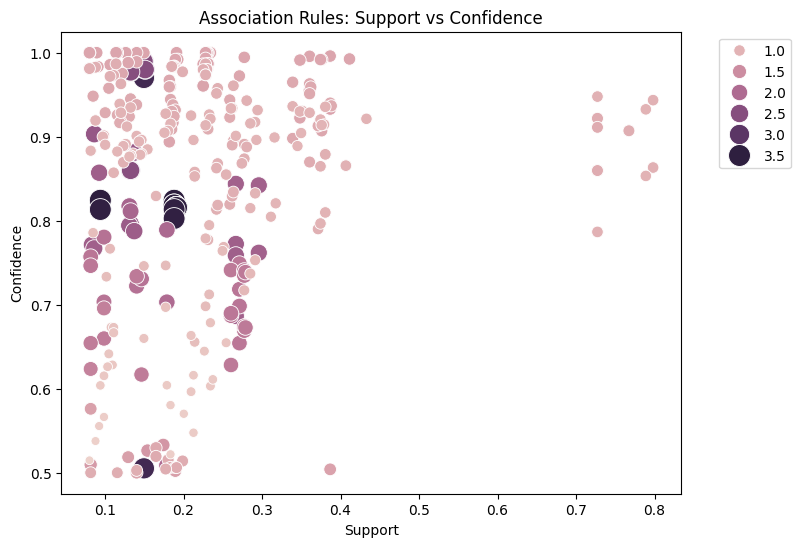

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [87]:
rules_plot = rules.copy()

rules_plot["support"] = rules_plot["support"].astype(float)
rules_plot["confidence"] = rules_plot["confidence"].astype(float)
rules_plot["lift"] = rules_plot["lift"].astype(float)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=rules_plot,
    x="support",
    y="confidence",
    size="lift",
    hue="lift",
    sizes=(40, 250)
)

plt.title("Association Rules: Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

***Tạo dữ liệu riêng cho cluster rules:***

In [88]:
# Dữ liệu riêng để khai phá luật liên quan đến cluster
df_cluster_assoc = df_cluster.copy()

cluster_features = ["studytime", "failures", "absences", "G1", "G2", "cluster_name"]
df_cluster_assoc = df_cluster_assoc[cluster_features].copy()

df_cluster_assoc.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,studytime,failures,absences,G1,G2,cluster_name
0,2,0,4,0,11,Hardworking students
1,2,0,2,9,11,Stable students
2,2,0,6,12,13,Hardworking students
3,3,0,0,14,14,High-performing students
4,2,0,0,11,13,High-performing students


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


***Rời rạc hóa các biến:***

In [89]:
df_cluster_assoc["G1_level"] = safe_qcut(df_cluster_assoc["G1"], q=3, labels=["low", "medium", "high"])
df_cluster_assoc["G2_level"] = safe_qcut(df_cluster_assoc["G2"], q=3, labels=["low", "medium", "high"])
df_cluster_assoc["absences_level"] = safe_qcut(df_cluster_assoc["absences"], q=3, labels=["low", "medium", "high"])

df_cluster_assoc["studytime_level"] = df_cluster_assoc["studytime"].map({
    1: "low",
    2: "medium",
    3: "high",
    4: "high"
})

df_cluster_assoc["failures_level"] = df_cluster_assoc["failures"].apply(
    lambda x: "none" if x == 0 else ("low" if x == 1 else "high")
)

df_cluster_assoc.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,studytime,failures,absences,G1,G2,cluster_name,G1_level,G2_level,absences_level,studytime_level,failures_level
0,2,0,4,0,11,Hardworking students,low,medium,low,medium,none
1,2,0,2,9,11,Stable students,low,medium,low,medium,none
2,2,0,6,12,13,Hardworking students,medium,medium,low,medium,none
3,3,0,0,14,14,High-performing students,high,high,low,high,none
4,2,0,0,11,13,High-performing students,medium,medium,low,medium,none


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


***Tạo transaction có cluster:***

In [90]:
transaction_cluster_df = pd.DataFrame({
    "studytime": "studytime_" + df_cluster_assoc["studytime_level"].astype(str),
    "failures": "failures_" + df_cluster_assoc["failures_level"].astype(str),
    "absences": "absences_" + df_cluster_assoc["absences_level"].astype(str),
    "G1": "G1_" + df_cluster_assoc["G1_level"].astype(str),
    "G2": "G2_" + df_cluster_assoc["G2_level"].astype(str),
    "cluster": "cluster_" + df_cluster_assoc["cluster_name"].astype(str)
})

transaction_cluster_df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,studytime,failures,absences,G1,G2,cluster
0,studytime_medium,failures_none,absences_low,G1_low,G2_medium,cluster_Hardworking students
1,studytime_medium,failures_none,absences_low,G1_low,G2_medium,cluster_Stable students
2,studytime_medium,failures_none,absences_low,G1_medium,G2_medium,cluster_Hardworking students
3,studytime_high,failures_none,absences_low,G1_high,G2_high,cluster_High-performing students
4,studytime_medium,failures_none,absences_low,G1_medium,G2_medium,cluster_High-performing students


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


***One-hot và chạy Apriori riêng cho cluster:***

In [91]:
basket_cluster = pd.get_dummies(transaction_cluster_df).astype(bool)

from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets_cluster = apriori(
    basket_cluster,
    min_support=0.08,
    use_colnames=True,
    max_len=3
)

frequent_itemsets_cluster = frequent_itemsets_cluster.sort_values(by="support", ascending=False)
frequent_itemsets_cluster.head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
5,0.924499,(absences_absences_low)
4,0.845917,(failures_failures_none)
42,0.798151,"(absences_absences_low, failures_failures_none)"
2,0.469954,(studytime_studytime_medium)
30,0.432974,"(absences_absences_low, studytime_studytime_me..."
11,0.414484,(G2_G2_medium)
29,0.406780,"(failures_failures_none, studytime_studytime_m..."
48,0.388290,"(G2_G2_medium, failures_failures_none)"
7,0.388290,(G1_G1_low)
97,0.380586,"(absences_absences_low, failures_failures_none..."


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


***Sinh luật cluster:***

In [92]:
rules_cluster_raw = association_rules(
    frequent_itemsets_cluster,
    metric="confidence",
    min_threshold=0.5
)

rules_cluster_raw = rules_cluster_raw.sort_values(
    by=["lift", "confidence", "support"],
    ascending=False
)

rules_cluster_raw.head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
140,(G1_G1_high),"(G2_G2_high, cluster_cluster_High-performing s...",0.234206,0.161787,0.141757,0.605263,3.741103,1.0,0.103865,2.123472,0.956784,0.557576,0.529073,0.740727
136,"(G2_G2_high, cluster_cluster_High-performing s...",(G1_G1_high),0.161787,0.234206,0.141757,0.876190,3.741103,1.0,0.103865,6.185255,0.874121,0.557576,0.838325,0.740727
138,"(cluster_cluster_High-performing students, G1_...",(G2_G2_high),0.163328,0.234206,0.141757,0.867925,3.705809,1.0,0.103504,5.798151,0.872688,0.554217,0.827531,0.736594
139,(G2_G2_high),"(cluster_cluster_High-performing students, G1_...",0.234206,0.163328,0.141757,0.605263,3.705809,1.0,0.103504,2.119569,0.953460,0.554217,0.528206,0.736594
82,"(absences_absences_low, G1_G1_high)",(G2_G2_high),0.228043,0.234206,0.187982,0.824324,3.519648,1.0,0.134572,4.359132,0.927358,0.685393,0.770597,0.813478
183,"(G1_G1_high, studytime_studytime_medium)",(G2_G2_high),0.114022,0.234206,0.093991,0.824324,3.519648,1.0,0.067286,4.359132,0.808011,0.369697,0.770597,0.612820
84,(G2_G2_high),"(absences_absences_low, G1_G1_high)",0.234206,0.228043,0.187982,0.802632,3.519648,1.0,0.134572,3.911248,0.934822,0.685393,0.744327,0.813478
77,"(failures_failures_none, G1_G1_high)",(G2_G2_high),0.229584,0.234206,0.187982,0.818792,3.496026,1.0,0.134211,4.226046,0.926721,0.681564,0.763372,0.810712
81,"(absences_absences_low, G2_G2_high)",(G1_G1_high),0.229584,0.234206,0.187982,0.818792,3.496026,1.0,0.134211,4.226046,0.926721,0.681564,0.763372,0.810712
78,(G2_G2_high),"(failures_failures_none, G1_G1_high)",0.234206,0.229584,0.187982,0.802632,3.496026,1.0,0.134211,3.903441,0.932315,0.681564,0.743816,0.810712


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


***Lọc luật có consequent là cluster:***

In [93]:
rules_cluster = rules_cluster_raw[
    rules_cluster_raw["consequents"].apply(lambda x: any("cluster_" in item for item in x))
].copy()

rules_cluster["antecedents"] = rules_cluster["antecedents"].apply(format_itemset)
rules_cluster["consequents"] = rules_cluster["consequents"].apply(format_itemset)

rules_cluster = rules_cluster[[
    "antecedents", "consequents", "support", "confidence", "lift"
]].sort_values(by=["lift", "confidence", "support"], ascending=False)

rules_cluster["support"] = rules_cluster["support"].round(4)
rules_cluster["confidence"] = rules_cluster["confidence"].round(4)
rules_cluster["lift"] = rules_cluster["lift"].round(4)

rules_cluster.head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
140,G1_G1_high,"G2_G2_high, cluster_cluster_High-performing st...",0.1418,0.6053,3.7411
139,G2_G2_high,"G1_G1_high, cluster_cluster_High-performing st...",0.1418,0.6053,3.7058
137,"G1_G1_high, G2_G2_high",cluster_cluster_High-performing students,0.1418,0.7419,2.4693
210,"G2_G2_high, studytime_studytime_medium",cluster_cluster_High-performing students,0.0832,0.7200,2.3963
117,G2_G2_high,"absences_absences_low, cluster_cluster_High-pe...",0.1587,0.6776,2.3518
104,"G1_G1_high, failures_failures_none",cluster_cluster_High-performing students,0.1618,0.7047,2.3454
216,"G1_G1_high, studytime_studytime_medium",cluster_cluster_High-performing students,0.0801,0.7027,2.3387
123,G1_G1_high,"absences_absences_low, cluster_cluster_High-pe...",0.1572,0.6711,2.3289
101,G1_G1_high,cluster_cluster_High-performing students,0.1633,0.6974,2.3210
106,G1_G1_high,"cluster_cluster_High-performing students, fail...",0.1618,0.6908,2.3109


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Tổng hợp luật kết hợp:**

In [94]:
top_rules_for_report = pd.concat([
    rules_fail.head(10),
    rules_pass.head(10),
    rules_cluster.head(10)
], axis=0).drop_duplicates().reset_index(drop=True)

top_rules_for_report

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
0,"G1_G1_low, G2_G2_low",pass_result_result_fail,0.1495,0.5052,3.2788
1,G2_G2_high,"G1_G1_high, pass_result_result_pass",0.1911,0.8158,3.4832
2,G1_G1_high,"G2_G2_high, pass_result_result_pass",0.1911,0.8158,3.4832
3,G2_G2_medium,"G1_G1_medium, pass_result_result_pass",0.2773,0.6691,1.7871
4,G1_G1_medium,"G2_G2_medium, pass_result_result_pass",0.2773,0.7347,1.7858
5,G2_G2_high,"failures_failures_none, pass_result_result_pass",0.2311,0.9868,1.2861
6,G1_G1_high,"failures_failures_none, pass_result_result_pass",0.2296,0.9803,1.2775
7,G1_G1_medium,"failures_failures_none, pass_result_result_pass",0.3606,0.9551,1.2447
8,G2_G2_high,"absences_absences_low, pass_result_result_pass",0.2296,0.9803,1.2426
9,G1_G1_high,"absences_absences_low, pass_result_result_pass",0.2280,0.9737,1.2342


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Bảng tóm tắt các luật kết hợp quan trọng**
| # | Luật kết hợp | Support (% SV) | Confidence (%) | Lift | Ý nghĩa |
|---|---|---|---|---|---|
| 1 | **G1_low ∧ G2_low → Fail** | 14.95 | 50.52 | **3.28** | Sinh viên có điểm thấp ở cả hai lần kiểm tra giữa kỳ có nguy cơ trượt rất cao |
| 2 | **G1_high → G2_high ∧ Pass** | 19.11 | 81.58 | **3.48** | Sinh viên có điểm cao từ đầu kỳ thường tiếp tục đạt kết quả tốt và qua môn |
| 3 | **G2_high → G1_high ∧ Pass** | 19.11 | 81.58 | **3.48** | Sinh viên học tốt thường duy trì điểm cao xuyên suốt học kỳ |
| 4 | **G2_medium → G1_medium ∧ Pass** | 27.73 | 66.91 | 1.79 | Sinh viên có học lực trung bình ổn định thường vẫn qua môn |
| 5 | **G1_medium → G2_medium ∧ Pass** | 27.73 | 73.47 | 1.79 | Điểm trung bình thường duy trì ổn định trong học kỳ |
| 6 | **G2_high → failures_none ∧ Pass** | 23.11 | 98.68 | 1.29 | Sinh viên điểm cao gần như không có lịch sử trượt và thường qua môn |
| 7 | **G1_high → absences_low ∧ Pass** | 22.80 | 97.37 | 1.23 | Sinh viên học tốt thường ít vắng học |
| 8 | **G1_high ∧ G2_high → High-performing cluster** | 14.18 | 74.19 | 2.47 | Sinh viên điểm cao ở cả hai lần kiểm tra thường thuộc nhóm học tốt |
| 9 | **G1_high ∧ failures_none → High-performing cluster** | 16.18 | 70.47 | 2.35 | Sinh viên điểm cao và không có lịch sử trượt thường thuộc nhóm học tốt |
|10 | **G1_high ∧ absences_low → High-performing cluster** | 15.72 | 67.11 | 2.33 | Sinh viên điểm cao và ít vắng học thường thuộc nhóm sinh viên giỏi |

**Insight chính:**

- **G1 và G2 là yếu tố dự báo mạnh nhất cho kết quả học tập.**
- **G1 thấp + G2 thấp → nguy cơ trượt cao gấp ~3.3 lần so với trung bình dataset.**
- **G1 cao + G2 cao → khả năng pass rất cao và thuộc nhóm sinh viên học tốt.**
- Sinh viên học tốt thường **ít vắng học và không có lịch sử trượt môn**.